In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logit, expit
from scipy.stats import linregress
from sklearn.linear_model import LinearRegression, LogisticRegression
from scipy.optimize import curve_fit
import pandas as pd

In [3]:
# data from Dickson et al.
reductions = np.array([0, .214, .242, .279, .32, .362, .415, .444])
brines = np.array([0, 247, 256, 264, 273, 281, 289, 292])
# calculate the molar mass of GSL Solvent 
M_nacl = 58.44
M_mgcl2 = 95.2
M_na2so4 = 142.04
M_kcl = 74.55
# use concentration percentages in Dickson et al.
M_Sol = (75.91*M_nacl + 10.92*M_mgcl2 + 9.52*M_na2so4 + 3.16*M_kcl)/(75.91 + 10.92 + 9.52 + 3.16)
# specific gravity data from Dickson et al.
SG = np.array([1, 1.188, 1.198, 1.208, 1.218, 1.229, 1.239, 1.244])
rho = 1000 * SG
factor = (2*75.91 + 3*10.92 + 3*9.52 + 2*3.16)/(75.91 + 10.92 + 9.52 + 3.16)
print(factor)
x_water = ((rho - brines) / 18.015)/(((rho - brines) / 18.015) + (2.2*brines/M_Sol))
reg = linregress(brines, SG - 1)
print(reg)
# regress on the specific gravity data to get a function 
def specific_gravity(c):
    return c*0.000812585 + 1
def mole_fracs(concentrations):
    sg = specific_gravity(concentrations)
    rho = 1000*sg
    return ((rho - concentrations) / 18.015)/(((rho - concentrations) / 18.015) + (factor*concentrations/M_Sol))

2.2054064918098684
LinregressResult(slope=0.0008125852930310412, intercept=-0.0026921534181300333, rvalue=0.9963183005911099, pvalue=1.2441851470577901e-07, stderr=2.8545278392211633e-05, intercept_stderr=0.007267254515661089)


/var/folders/4c/sh6kr5rx02jgqlwfm4gwl5cw0000gn/T/ipykernel_26060/2111764936.py:6: RuntimeWarning: overflow encountered in exp
  return 0.9 / (1 + np.exp(-k*(x - x0)))


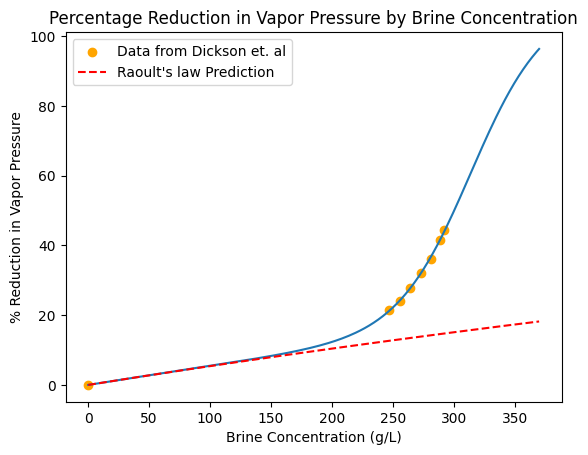

In [7]:
c = np.linspace(0, 370, 200)

idio_reds = reductions - (1 - mole_fracs(brines))
y = idio_reds
def logistic(x, k, x0):
    return 0.9 / (1 + np.exp(-k*(x - x0)))
xdata = brines
ydata = idio_reds
params, cov = curve_fit(logistic, xdata, ydata, p0=[1, 300])
k = params[0]
x0 = params[1]
# L = params[2]
vp_reduc = (logistic(c, k, x0) + (1 - mole_fracs(c)))
plt.plot(c, 100*vp_reduc)
plt.scatter(brines, 100*reductions, label="Data from Dickson et. al", color='orange')
plt.xlabel("Brine Concentration (g/L)")
plt.ylabel("% Reduction in Vapor Pressure")
plt.plot(c, 100*(1 - mole_fracs(c)), linestyle='dashed', color='red', label="Raoult's law Prediction")
plt.legend()
plt.title("Percentage Reduction in Vapor Pressure by Brine Concentration")
plt.savefig("./images/es_reduction_model.jpg")
plt.show()

In [8]:
dict = {}
dict["salinity"] = c
dict["vp_reduction"] = vp_reduc
df = pd.DataFrame(dict)
df.to_csv("./data/vp-salinity.csv")